In [22]:
from dl_assignment_2.data.dataFolderReader import FolderDataReader
from dl_assignment_2.data.dataSegment import DataSegment
from dl_assignment_2.modeling.trainer import TrainConfig
from dl_assignment_2.modeling.dataset import CustomDataset
from dl_assignment_2.modeling.model import SimpleRNN
from dl_assignment_2.modeling.trainer import Trainer
from dl_assignment_2.data.pipeline import Pipeline
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import Adam

In [23]:
train_data: list[DataSegment] = FolderDataReader("../../datasets/Intra/train").get_all_segments()
train_data = train_data[:3]
dataset = CustomDataset(train_data, Pipeline())

reading file: task_motor_105923_2.h5
reading file: task_motor_105923_5.h5
reading file: task_motor_105923_6.h5
reading file: task_working_memory_105923_3.h5
reading file: task_motor_105923_3.h5
reading file: task_motor_105923_7.h5
reading file: task_story_math_105923_3.h5
reading file: task_working_memory_105923_1.h5
reading file: task_story_math_105923_2.h5
reading file: task_story_math_105923_6.h5
reading file: rest_105923_5.h5
reading file: task_working_memory_105923_6.h5
reading file: task_motor_105923_1.h5
reading file: task_story_math_105923_1.h5
reading file: rest_105923_7.h5
reading file: rest_105923_3.h5
reading file: task_story_math_105923_4.h5
reading file: rest_105923_8.h5
reading file: task_working_memory_105923_2.h5
reading file: task_motor_105923_4.h5
reading file: rest_105923_4.h5
reading file: task_story_math_105923_8.h5
reading file: task_story_math_105923_7.h5
reading file: task_working_memory_105923_4.h5
reading file: task_working_memory_105923_7.h5
reading file: ta

In [24]:
loader = DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=True, 
    num_workers=4,       # Loads data in parallel using CPU cores
    pin_memory=True      # Allows faster memory transfer to the GPU
)
config: TrainConfig = TrainConfig(8, CrossEntropyLoss, Adam, 0.05)

In [25]:
train_data[0].data.shape

(248, 35624)

epoch: 1
training time: 0.17956829071044922
eval time: 0.15145444869995117
epoch: 2
training time: 0.1846787929534912
eval time: 0.15713024139404297
epoch: 3
training time: 0.17358684539794922
eval time: 0.14883136749267578
epoch: 4
training time: 0.17424941062927246
eval time: 0.1469881534576416
epoch: 5
training time: 0.16960954666137695
eval time: 0.1442115306854248
epoch: 6
training time: 0.17002296447753906
eval time: 0.14436054229736328
epoch: 7
training time: 0.17669296264648438
eval time: 0.1458415985107422
epoch: 8
training time: 0.1695256233215332
eval time: 0.1535663604736328


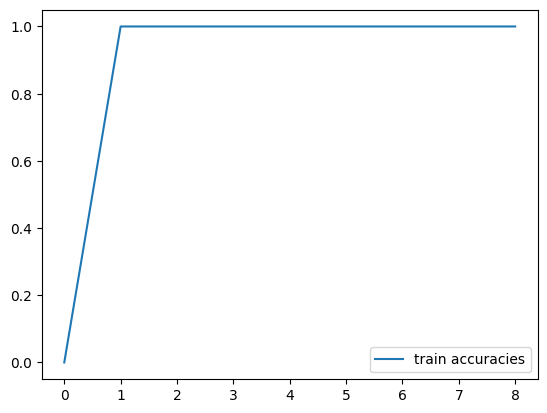

<Axes: >

In [26]:
rnn = SimpleRNN(248, 124, 4)

trainer = Trainer(rnn, loader, config)
trainer.train()
trainer.plot_accuracy()

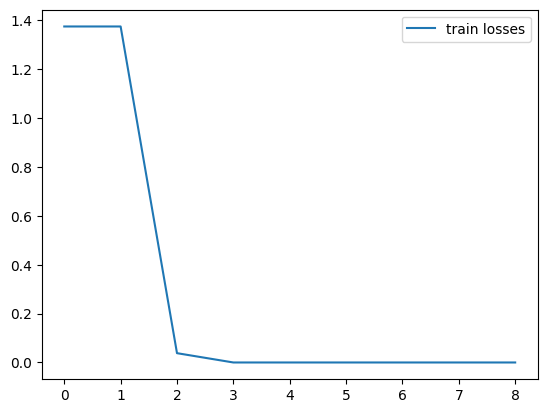

<Axes: >

In [27]:
import matplotlib.pyplot as plt
trainer.plot_losses()

In [28]:
trainer.train_losses

[1.3742848634719849,
 1.3742848634719849,
 0.038070790469646454,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]